# Asistente Inteligente para la Planeación del Súper Semanal

Proyecto Final – Inteligencia Artificial Aplicada

Autora:
Imelda Natalia Jiménez Altamirano

Objetivo:
Construir un asistente inteligente que ayude a los hogares a planificar sus compras semanales minimizando costo y desperdicio.

## 1. Descripción general de la solución

Este proyecto propone un asistente inteligente para apoyar la planeación semanal
de compras de alimentos en hogares. La solución combina técnicas de aprendizaje
automático y optimización para generar recomendaciones que reduzcan costos y
desperdicio alimentario respetando restricciones de presupuesto, inventario,
preferencias alimentarias y alergias.
 
El flujo general de trabajo es el siguiente:
 
1. Cargar y validar los conjuntos de datos.
2. Realizar análisis exploratorio para comprender los patrones de consumo.
3. Entrenar un modelo predictivo basado en Árboles de Decisión.
4. Estimar el consumo esperado de ingredientes.
5. Utilizar dichas predicciones como entrada para un modelo de optimización CP-SAT.
6. Generar menús semanales y listas de compra optimizadas.
7. Evaluar escenarios factibles e infactibles.
8. Analizar beneficios, riesgos y viabilidad de la solución.

## 2. Preparación del entorno

En esta etapa se importan las librerías necesarias para el desarrollo del
proyecto.

Las principales herramientas utilizadas son:
 
- pandas: manipulación y análisis de datos.
- numpy: operaciones numéricas.
- matplotlib y seaborn: visualización y análisis gráfico.
- scikit-learn: desarrollo del modelo predictivo basado en Árboles de Decisión.
- Google OR-Tools (CP-SAT): optimización de menús y listas de compra mediante
programación por restricciones.
 
También se verifica la estructura del proyecto y la disponibilidad de los
archivos CSV que contienen la información utilizada por el sistema.

**Carga de librerias**

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


**Preparación - Cargar CVS**

In [3]:
import pandas as pd

hogares = pd.read_csv("../data/hogares.csv")
ingredientes = pd.read_csv("../data/ingredientes.csv")
recetas = pd.read_csv("../data/recetas.csv")
receta_ingredientes = pd.read_csv("../data/receta_ingredientes.csv")
catalogo = pd.read_csv("../data/catalogo_supermercado.csv")
historial = pd.read_csv("../data/historial_consumo.csv")

print("Hogares:", hogares.shape)
print("Ingredientes:", ingredientes.shape)
print("Recetas:", recetas.shape)
print("Relaciones:", receta_ingredientes.shape)
print("Catálogo:", catalogo.shape)
print("Historial:", historial.shape)

Hogares: (10, 9)
Ingredientes: (24, 7)
Recetas: (15, 7)
Relaciones: (77, 3)
Catálogo: (48, 8)
Historial: (768, 9)


**Visualizar los primeros registros**

In [4]:
hogares.head()

,hogar_id,numero_integrantes,adultos,ninos,presupuesto_semanal_mxn,preferencia_alimentaria,alergenos_excluidos,objetivo_principal,acepta_sugerencias
0,H001,2,2,0,1250,Omnívora,Ninguna,Costo bajo,Sí
1,H002,4,2,2,1850,Omnívora,Cacahuate,Variedad familiar,Sí
2,H003,3,2,1,1600,Vegetariana,Ninguna,Más vegetales,No
3,H004,1,1,0,750,Omnívora,Lactosa,Preparación rápida,Sí
4,H005,5,3,2,2300,Omnívora,Mariscos,Porciones abundantes,Sí


In [5]:
ingredientes.head()

,ingrediente_id,nombre,categoria,unidad,vida_util_dias,alergeno_asociado,activo
0,I001,Arroz,Cereal,g,365,Ninguno,1
1,I002,Pasta,Cereal,g,365,Gluten,1
2,I003,Tortilla de maíz,Cereal,pieza,14,Ninguno,1
3,I004,Avena,Cereal,g,180,Gluten,1
4,I005,Frijol negro,Leguminosa,g,365,Ninguno,1


In [6]:
historial.head()

,hogar_id,semana_inicio,ingrediente_id,cantidad_comprada,cantidad_consumida,cantidad_desperdiciada,inventario_final,aceptacion_1_5,unidad
0,H001,2026-07-06,I001,406.7,332.5,49.5,24.7,4,g
1,H001,2026-07-06,I022,2.3,1.5,0.2,0.6,3,pieza
2,H001,2026-07-06,I018,185.0,150.7,22.0,12.3,4,g
3,H001,2026-07-06,I005,162.2,120.3,20.1,21.8,4,g
4,H001,2026-07-06,I021,379.0,337.2,28.6,13.2,4,g


## 3. Exploración de Datos (EDA)

En esta sección se realiza un análisis exploratorio de los datos sintéticos utilizados para desarrollar el asistente inteligente de planeación del súper semanal.

El objetivo es comprender la estructura de los datos, identificar patrones de consumo y validar que la información es adecuada para el entrenamiento del modelo predictivo y el proceso de optimización.

**Información general de los datasets**

In [8]:
print("=== HOGARES ===")
hogares.info()

print("\n=== INGREDIENTES ===")
ingredientes.info()

print("\n=== HISTORIAL ===")
historial.info()

=== HOGARES ===
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   hogar_id                 10 non-null     str  
 1   numero_integrantes       10 non-null     int64
 2   adultos                  10 non-null     int64
 3   ninos                    10 non-null     int64
 4   presupuesto_semanal_mxn  10 non-null     int64
 5   preferencia_alimentaria  10 non-null     str  
 6   alergenos_excluidos      10 non-null     str  
 7   objetivo_principal       10 non-null     str  
 8   acepta_sugerencias       10 non-null     str  
dtypes: int64(4), str(5)
memory usage: 852.0 bytes

=== INGREDIENTES ===
<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ingrediente_id     24 non-null     str  
 1   nombre         

**Estadisticas descriptivas**

In [9]:
historial.describe()

,cantidad_comprada,cantidad_consumida,cantidad_desperdiciada,inventario_final,aceptacion_1_5
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,438.082031,333.755729,43.992318,60.333984,3.975260
std,308.500705,233.838849,46.267287,59.432586,0.807825
min,1.000000,0.700000,0.000000,0.000000,3.000000
25%,224.275000,182.850000,13.400000,18.800000,3.000000
50%,379.600000,288.600000,29.400000,41.350000,4.000000
75%,607.600000,457.525000,59.625000,84.950000,5.000000
max,1523.900000,1157.600000,366.800000,359.300000,5.000000


**Cargar librerias para las gráficas**

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Matplotlib is building the font cache; this may take a moment.


**Primera Gráfica (Consumo)**

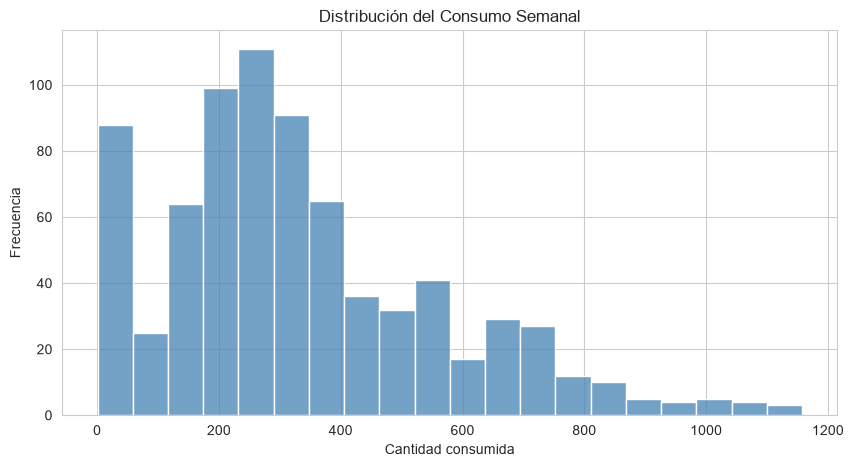

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    historial["cantidad_consumida"],
    bins=20,
    color="steelblue"
)

plt.title("Distribución del Consumo Semanal")
plt.xlabel("Cantidad consumida")
plt.ylabel("Frecuencia")

plt.show()

**Segunda Gráfica (Compra vs Consumo)**

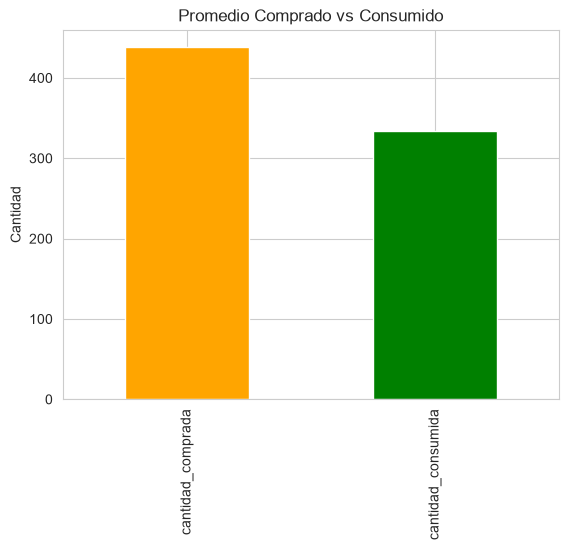

In [12]:
promedios = historial[
    ["cantidad_comprada","cantidad_consumida"]
].mean()

promedios.plot(
    kind="bar",
    color=["orange","green"]
)

plt.title("Promedio Comprado vs Consumido")
plt.ylabel("Cantidad")

plt.show()

**Tercera Gráfica (Desperdicio)**

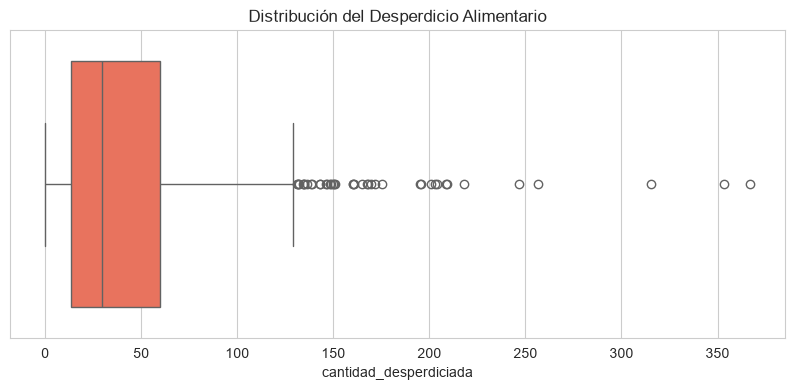

In [15]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=historial["cantidad_desperdiciada"],
    color="tomato"
)

plt.title("Distribución del Desperdicio Alimentario")

plt.show()

## 4. Modelo Predictivo (Árbol de decisión)

Se implementa un modelo de Árbol de Decisión para estimar el consumo semanal esperado de ingredientes a partir de variables históricas de compra, inventario y aceptación.
`

In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

**Construcción del Dataset de entrenamiento**

In [20]:
dataset = historial.merge(
    hogares[["hogar_id",
             "numero_integrantes",
             "adultos",
             "ninos"]],
    on="hogar_id"
)

dataset.head()

,hogar_id,semana_inicio,ingrediente_id,cantidad_comprada,cantidad_consumida,cantidad_desperdiciada,inventario_final,aceptacion_1_5,unidad,numero_integrantes,adultos,ninos
0,H001,2026-07-06,I001,406.7,332.5,49.5,24.7,4,g,2,2,0
1,H001,2026-07-06,I022,2.3,1.5,0.2,0.6,3,pieza,2,2,0
2,H001,2026-07-06,I018,185.0,150.7,22.0,12.3,4,g,2,2,0
3,H001,2026-07-06,I005,162.2,120.3,20.1,21.8,4,g,2,2,0
4,H001,2026-07-06,I021,379.0,337.2,28.6,13.2,4,g,2,2,0


In [21]:
X = dataset[
    [
        "numero_integrantes",
        "adultos",
        "ninos",
        "cantidad_comprada",
        "inventario_final",
        "aceptacion_1_5"
    ]
]

y = dataset["cantidad_consumida"]

Dividir Datos

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (614, 6)
Prueba: (154, 6)


**Entrenar árbol**

In [23]:
modelo = DecisionTreeRegressor(
    max_depth=6,
    random_state=42
)

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


**Evaluar Modelo**

In [24]:
predicciones = modelo.predict(X_test)

mae = mean_absolute_error(
    y_test,
    predicciones
)

rmse = mean_squared_error(
    y_test,
    predicciones
) ** 0.5

r2 = r2_score(
    y_test,
    predicciones
)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,2))

MAE : 28.64
RMSE: 45.97
R²  : 0.96


### **Ejemplo de Predicción**
 
Se simuló un hogar con cuatro integrantes, dos adultos y dos niños, con un historial de compra de 500 unidades, un inventario disponible de 50 unidades y un nivel de aceptación de 4 sobre 5.
 
El modelo estimó un consumo esperado de 359.54 unidades. Esta predicción será utilizada posteriormente por el modelo de optimización para determinar las cantidades de compra recomendadas.

In [26]:
nuevo_hogar = pd.DataFrame({
    "numero_integrantes":[4],
    "adultos":[2],
    "ninos":[2],
    "cantidad_comprada":[500],
    "inventario_final":[50],
    "aceptacion_1_5":[4]
})

consumo_estimado = modelo.predict(nuevo_hogar)

print("Consumo estimado:", round(consumo_estimado[0],2))

Consumo estimado: 359.54


## 5. Optimización mediante IA Simbólica (CP-SAT)
En esta etapa se utiliza programación por restricciones para seleccionar recetas compatibles con las necesidades del hogar, respetando restricciones de presupuesto y disponibilidad de ingredientes.
 
La optimización utiliza como entrada el consumo estimado por el modelo predictivo.

In [30]:
import sys

print(sys.version)

3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]


In [31]:
import ortools
print(ortools.__version__)

9.15.6755


In [32]:
from ortools.sat.python import cp_model

modelo_cp = cp_model.CpModel()

x = modelo_cp.NewBoolVar("Arroz_con_Pollo")
y = modelo_cp.NewBoolVar("Tacos_de_Frijol")

modelo_cp.Add(x + y == 1)

modelo_cp.Maximize(
    5*x + 4*y
)

solver = cp_model.CpSolver()

status = solver.Solve(modelo_cp)

if status == cp_model.OPTIMAL:
    print("OPTIMAL")
    print("Arroz con Pollo:", solver.Value(x))
    print("Tacos de Frijol:", solver.Value(y))

OPTIMAL
Arroz con Pollo: 1
Tacos de Frijol: 0


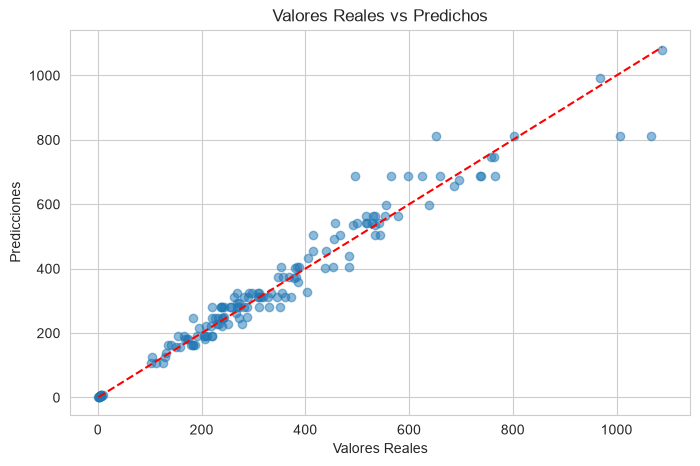

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, predicciones, alpha=0.5)

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")

plt.title("Valores Reales vs Predichos")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

## 6. Optimización mediante IA simbólica con CP-SAT

En esta sección se utiliza programación por restricciones para generar un plan semanal de comidas y una lista de compra. El modelo selecciona recetas compatibles con las características del hogar, calcula los ingredientes necesarios y determina el número entero de paquetes que deben comprarse.

La función objetivo minimiza el costo de compra, los sobrantes estimados y la selección de recetas con baja aceptación. Las restricciones consideran el presupuesto semanal, las preferencias alimentarias, las alergias, el inventario existente, la disponibilidad de productos y la compra de paquetes completos.

**6.1 Seleccionar hogar**
Usaremos inicialmente H001, que tiene dos integrantes, presupuesto de $1,250 MXN, alimentación omnívora y ninguna alergia.

In [70]:
hogar_id = "H001"

hogar_seleccionado = hogares[
    hogares["hogar_id"] == hogar_id
].iloc[0]

display(hogar_seleccionado)

hogar_id                         H001
numero_integrantes                  2
adultos                             2
ninos                               0
presupuesto_semanal_mxn          1250
preferencia_alimentaria      Omnívora
alergenos_excluidos           Ninguna
objetivo_principal         Costo bajo
acepta_sugerencias                 Sí
Name: 0, dtype: object

**6.2 Función para separar alergias**

La base puede contener valores como:

- Ninguna
- Lácteos;Huevo
- Gluten
- Cacahuate

In [71]:
def separar_restricciones(texto):
    if pd.isna(texto):
        return set()
    
    texto = str(texto).strip().lower()
    
    if texto in {"", "ninguna", "ninguno"}:
        return set()
    
    return {
        elemento.strip()
        for elemento in texto.split(";")
        if elemento.strip()
    }

In [72]:
print(separar_restricciones("Lácteos;Huevo"))
print(separar_restricciones("Ninguna"))


{'lácteos', 'huevo'}
set()


**6.3 Filtrar recetas por preferencia alimentaria**

Aquí se determina qué tipo de recetas puede consumir el hogar

In [73]:
preferencia = str(
    hogar_seleccionado["preferencia_alimentaria"]
).strip().lower()

tipos_permitidos = {
    "vegana": {"vegana"},
    "vegetariana": {"vegana", "vegetariana"},
    "pescetariana": {"vegana", "vegetariana", "pescetariana"},
    "omnívora": {
        "vegana",
        "vegetariana",
        "pescetariana",
        "omnívora"
    },
    "omnivora": {
        "vegana",
        "vegetariana",
        "pescetariana",
        "omnívora"
    }
}

alimentaciones_permitidas = tipos_permitidos.get(
    preferencia,
    {preferencia}
)

recetas_permitidas = recetas[
    recetas["tipo_alimentacion"]
    .str.strip()
    .str.lower()
    .isin(alimentaciones_permitidas)
].copy()

print("Preferencia del hogar:", preferencia)
print("Recetas compatibles por alimentación:", len(recetas_permitidas))

display(
    recetas_permitidas[
        ["receta_id", "nombre", "tipo_alimentacion",
         "nivel_aceptacion_base_1_5"]
    ]
)

Preferencia del hogar: omnívora
Recetas compatibles por alimentación: 15


,receta_id,nombre,tipo_alimentacion,nivel_aceptacion_base_1_5
0,R001,Arroz con pollo y verduras,Omnívora,5
1,R002,Pasta con carne y jitomate,Omnívora,4
2,R003,Tacos de frijol con aguacate,Vegana,5
3,R004,Lentejas con verduras,Vegana,4
4,R005,Ensalada de garbanzo,Vegana,4
5,R006,Omelette de espinaca y queso,Vegetariana,5
6,R007,Avena con leche y manzana,Vegetariana,5
7,R008,Tostadas de atún,Pescetariana,4
8,R009,Picadillo con papa y zanahoria,Omnívora,5
9,R010,Tofu salteado con arroz,Vegana,4


**6.4 Eliminar receras incompatibles con alergias**

Se revisa los ingredientes de cada receta


In [74]:
alergias_hogar = separar_restricciones(
    hogar_seleccionado["alergenos_excluidos"]
)

mapa_alergenos = ingredientes.set_index(
    "ingrediente_id"
)["alergeno_asociado"].to_dict()

recetas_prohibidas = set()

for fila in receta_ingredientes.itertuples():
    alergenos_ingrediente = separar_restricciones(
        mapa_alergenos[fila.ingrediente_id]
    )
    
    if alergias_hogar.intersection(alergenos_ingrediente):
        recetas_prohibidas.add(fila.receta_id)

recetas_permitidas = recetas_permitidas[
    ~recetas_permitidas["receta_id"].isin(recetas_prohibidas)
].copy()

print("Alergias excluidas:", alergias_hogar)
print("Recetas eliminadas por alergias:", len(recetas_prohibidas))
print("Recetas finalmente permitidas:", len(recetas_permitidas))

display(
    recetas_permitidas[
        ["receta_id", "nombre", "tipo_alimentacion"]
    ]
)

Alergias excluidas: set()
Recetas eliminadas por alergias: 0
Recetas finalmente permitidas: 15


,receta_id,nombre,tipo_alimentacion
0,R001,Arroz con pollo y verduras,Omnívora
1,R002,Pasta con carne y jitomate,Omnívora
2,R003,Tacos de frijol con aguacate,Vegana
3,R004,Lentejas con verduras,Vegana
4,R005,Ensalada de garbanzo,Vegana
5,R006,Omelette de espinaca y queso,Vegetariana
6,R007,Avena con leche y manzana,Vegetariana
7,R008,Tostadas de atún,Pescetariana
8,R009,Picadillo con papa y zanahoria,Omnívora
9,R010,Tofu salteado con arroz,Vegana


**6.5 Obtener inventario disponible**

Utilizaremos el inventario final del registro histórico más reciente de cada ingrediente para el hogar seleccionado.

In [75]:
historial_hogar = historial[
    historial["hogar_id"] == hogar_id
].copy()

historial_hogar["semana_inicio"] = pd.to_datetime(
    historial_hogar["semana_inicio"]
)

inventario_actual = (
    historial_hogar
    .sort_values("semana_inicio")
    .groupby("ingrediente_id", as_index=False)
    .tail(1)
    [["ingrediente_id", "inventario_final"]]
)

inventario_actual = inventario_actual.set_index(
    "ingrediente_id"
)["inventario_final"].to_dict()

print("Ingredientes con inventario registrado:", len(inventario_actual))
print(inventario_actual)

Ingredientes con inventario registrado: 10
{'I006': 39.2, 'I001': 34.4, 'I022': 0.0, 'I018': 44.8, 'I005': 41.1, 'I021': 15.8, 'I002': 23.4, 'I014': 31.7, 'I009': 25.8, 'I013': 18.8}


**6.6 Seleccionar el producto disponible con menor costo por unidad**

Para cada ingrediente tomaremos la presentación disponible con menor costo por unidad.

In [76]:
productos_disponibles = catalogo[
    catalogo["disponible"] == 1
].copy()

productos_disponibles["costo_por_unidad"] = (
    productos_disponibles["precio_mxn"]
    / productos_disponibles["cantidad_por_paquete"]
)

productos_elegidos = (
    productos_disponibles
    .sort_values(
        ["ingrediente_id", "costo_por_unidad", "precio_mxn"]
    )
    .groupby("ingrediente_id", as_index=False)
    .first()
)

productos_elegidos = productos_elegidos.set_index(
    "ingrediente_id",
    drop=False
)

display(
    productos_elegidos[
        [
            "ingrediente_id",
            "producto_id",
            "marca",
            "cantidad_por_paquete",
            "precio_mxn",
            "costo_por_unidad"
        ]
    ]
)

,ingrediente_id,producto_id,marca,cantidad_por_paquete,precio_mxn,costo_por_unidad
ingrediente_id,,,,,,
I001,I001,P001,Ahorro,1000,42.5,0.042500
I002,I002,P003,Buen Día,500,31.9,0.063800
I003,I003,P005,Casa Verde,30,27.5,0.916667
I004,I004,P007,Ahorro,500,39.9,0.079800
I005,I005,P009,Buen Día,900,38.0,0.042222
I006,I006,P011,Casa Verde,500,31.0,0.062000
I007,I007,P013,Ahorro,500,36.0,0.072000
I008,I008,P015,Buen Día,1000,159.0,0.159000
I009,I009,P017,Casa Verde,500,98.0,0.196000


**6.7 Función del modelo CP-SAT**

In [77]:
from ortools.sat.python import cp_model

def resolver_menu_semanal(
    hogar_id,
    presupuesto_personalizado=None,
    comidas_semana=7
):
    hogar = hogares[
        hogares["hogar_id"] == hogar_id
    ].iloc[0]
    
    presupuesto = (
        float(presupuesto_personalizado)
        if presupuesto_personalizado is not None
        else float(hogar["presupuesto_semanal_mxn"])
    )
    
    preferencia = str(
        hogar["preferencia_alimentaria"]
    ).strip().lower()
    
    permitidos = tipos_permitidos.get(
        preferencia,
        {preferencia}
    )
    
    candidatos = recetas[
        recetas["tipo_alimentacion"]
        .str.strip()
        .str.lower()
        .isin(permitidos)
    ].copy()
    
    alergias = separar_restricciones(
        hogar["alergenos_excluidos"]
    )
    
    prohibidas = set()
    
    for fila in receta_ingredientes.itertuples():
        alergenos_ingrediente = separar_restricciones(
            mapa_alergenos[fila.ingrediente_id]
        )
        
        if alergias.intersection(alergenos_ingrediente):
            prohibidas.add(fila.receta_id)
    
    candidatos = candidatos[
        ~candidatos["receta_id"].isin(prohibidas)
    ].copy()
    
    ids_recetas = candidatos["receta_id"].tolist()
    
    if len(ids_recetas) == 0:
        return {
            "estado": "INFEASIBLE",
            "causas": [
                "No existen recetas compatibles con las restricciones del hogar."
            ]
        }
    
    modelo_cp = cp_model.CpModel()
    
    # Cantidad de veces que se selecciona cada receta.
    # Máximo dos veces para fomentar variedad.
    seleccionar = {
        receta_id: modelo_cp.new_int_var(
            0,
            2,
            f"seleccionar_{receta_id}"
        )
        for receta_id in ids_recetas
    }
    
    # Deben planificarse exactamente siete preparaciones.
    modelo_cp.add(
        sum(seleccionar.values()) == comidas_semana
    )
    
    relaciones_validas = receta_ingredientes[
        receta_ingredientes["receta_id"].isin(ids_recetas)
    ].copy()
    
    ingredientes_requeridos = sorted(
        relaciones_validas["ingrediente_id"].unique()
    )
    
    paquetes = {}
    sobrantes = {}
    demanda = {}
    ingredientes_sin_producto = []
    
    for ingrediente_id in ingredientes_requeridos:
        relaciones_ingrediente = relaciones_validas[
            relaciones_validas["ingrediente_id"] == ingrediente_id
        ]
        
        demanda[ingrediente_id] = sum(
            int(round(fila.cantidad_requerida))
            * seleccionar[fila.receta_id]
            for fila in relaciones_ingrediente.itertuples()
        )
        
        inventario = int(round(
            inventario_actual.get(ingrediente_id, 0)
        ))
        
        if ingrediente_id in productos_elegidos.index:
            cantidad_paquete = int(round(
                productos_elegidos.loc[
                    ingrediente_id,
                    "cantidad_por_paquete"
                ]
            ))
            
            paquetes[ingrediente_id] = modelo_cp.new_int_var(
                0,
                50,
                f"paquetes_{ingrediente_id}"
            )
            
            sobrantes[ingrediente_id] = modelo_cp.new_int_var(
                0,
                100000,
                f"sobrante_{ingrediente_id}"
            )
            
            modelo_cp.add(
                inventario
                + cantidad_paquete * paquetes[ingrediente_id]
                - demanda[ingrediente_id]
                == sobrantes[ingrediente_id]
            )
        
        else:
            ingredientes_sin_producto.append(ingrediente_id)
            
            # Si no existe producto disponible,
            # la demanda solo puede cubrirse con inventario.
            modelo_cp.add(
                demanda[ingrediente_id] <= inventario
            )
    
    # CP-SAT usa enteros, por eso los precios se convierten a centavos.
    costo_total_centavos = sum(
        int(round(
            productos_elegidos.loc[
                ingrediente_id,
                "precio_mxn"
            ] * 100
        )) * variable_paquetes
        for ingrediente_id, variable_paquetes in paquetes.items()
    )
    
    modelo_cp.add(
        costo_total_centavos
        <= int(round(presupuesto * 100))
    )
    
    recetas_indice = candidatos.set_index("receta_id")
    
    penalizacion_aceptacion = sum(
        (
            5
            - int(
                recetas_indice.loc[
                    receta_id,
                    "nivel_aceptacion_base_1_5"
                ]
            )
        )
        * 500
        * seleccionar[receta_id]
        for receta_id in ids_recetas
    )
    
    penalizacion_sobrantes = sum(
        sobrantes.values()
    )
    
    modelo_cp.minimize(
        costo_total_centavos
        + penalizacion_sobrantes
        + penalizacion_aceptacion
    )
    
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 15
    solver.parameters.num_search_workers = 8
    
    estado = solver.solve(modelo_cp)
    
    nombres_estado = {
        cp_model.OPTIMAL: "OPTIMAL",
        cp_model.FEASIBLE: "FEASIBLE",
        cp_model.INFEASIBLE: "INFEASIBLE",
        cp_model.MODEL_INVALID: "MODEL_INVALID",
        cp_model.UNKNOWN: "UNKNOWN"
    }
    
    resultado = {
        "estado": nombres_estado.get(estado, str(estado)),
        "solver": solver,
        "seleccionar": seleccionar,
        "paquetes": paquetes,
        "sobrantes": sobrantes,
        "costo_total_centavos": costo_total_centavos,
        "candidatos": candidatos,
        "productos": productos_elegidos,
        "presupuesto": presupuesto,
        "ingredientes_sin_producto": ingredientes_sin_producto
    }
    
    return resultado

**6.8 Ejecutar caso factible**

Como referencia:
- OPTIMAL: encontró la mejor solución demostrable.
- FEASIBLE: encontró una solución válida, pero no demostró que sea la mejor.
- INFEASIBLE: no existe solución que cumpla todas las restricciones.

In [78]:
resultado_factible = resolver_menu_semanal(
    hogar_id="H001"
)

print("Estado del modelo:", resultado_factible["estado"])
print(
    "Presupuesto:",
    resultado_factible["presupuesto"],
    "MXN"
)

Estado del modelo: OPTIMAL
Presupuesto: 1250.0 MXN


**6.9 Mostrar el menú seleccionado**

In [79]:
if resultado_factible["estado"] in {"OPTIMAL", "FEASIBLE"}:
    
    solver = resultado_factible["solver"]
    candidatos = resultado_factible["candidatos"].set_index(
        "receta_id"
    )
    
    menu_semanal = []
    
    for receta_id, variable in resultado_factible[
        "seleccionar"
    ].items():
        
        veces = solver.value(variable)
        
        if veces > 0:
            menu_semanal.append({
                "receta_id": receta_id,
                "receta": candidatos.loc[receta_id, "nombre"],
                "veces_en_semana": veces,
                "aceptacion": candidatos.loc[
                    receta_id,
                    "nivel_aceptacion_base_1_5"
                ]
            })
    
    menu_semanal = pd.DataFrame(menu_semanal)
    
    display(menu_semanal)
else:
    print("No se generó menú porque el modelo es infactible.")

,receta_id,receta,veces_en_semana,aceptacion
0,R004,Lentejas con verduras,2,4
1,R005,Ensalada de garbanzo,2,4
2,R007,Avena con leche y manzana,2,5
3,R014,Tortitas de garbanzo y espinaca,1,3


**6.10 Mostrar la lista de compras**

In [80]:
if resultado_factible["estado"] in {"OPTIMAL", "FEASIBLE"}:
    
    solver = resultado_factible["solver"]
    lista_compra = []
    
    for ingrediente_id, variable in resultado_factible[
        "paquetes"
    ].items():
        
        numero_paquetes = solver.value(variable)
        
        if numero_paquetes > 0:
            producto = resultado_factible[
                "productos"
            ].loc[ingrediente_id]
            
            sobrante = solver.value(
                resultado_factible[
                    "sobrantes"
                ][ingrediente_id]
            )
            
            lista_compra.append({
                "ingrediente_id": ingrediente_id,
                "producto_id": producto["producto_id"],
                "marca": producto["marca"],
                "paquetes": numero_paquetes,
                "cantidad_paquete": producto[
                    "cantidad_por_paquete"
                ],
                "precio_unitario_mxn": producto[
                    "precio_mxn"
                ],
                "subtotal_mxn": round(
                    numero_paquetes
                    * producto["precio_mxn"],
                    2
                ),
                "sobrante_estimado": sobrante
            })
    
    lista_compra = pd.DataFrame(lista_compra)
    
    display(lista_compra)
    
    costo_total_mxn = (
        solver.value(
            resultado_factible[
                "costo_total_centavos"
            ]
        ) / 100
    )
    
    print(
        "Costo total estimado:",
        round(costo_total_mxn, 2),
        "MXN"
    )
    
    print(
        "Presupuesto disponible:",
        resultado_factible["presupuesto"],
        "MXN"
    )

,ingrediente_id,producto_id,marca,paquetes,cantidad_paquete,precio_unitario_mxn,subtotal_mxn,sobrante_estimado
0,I004,P007,Ahorro,1,500,39.9,39.9,180
1,I006,P011,Casa Verde,2,500,31.0,62.0,339
2,I007,P013,Ahorro,2,500,36.0,72.0,50
3,I012,P023,Casa Verde,1,1000,29.5,29.5,0
4,I015,P029,Casa Verde,1,1000,39.0,39.0,0
5,I016,P031,Ahorro,1,1000,34.0,34.0,560
6,I017,P033,Buen Día,1,1000,29.0,29.0,480
7,I019,P037,Ahorro,2,300,35.0,70.0,150
8,I022,P043,Ahorro,1,6,44.0,44.0,2
9,I023,P045,Buen Día,1,900,49.0,49.0,790


Costo total estimado: 468.4 MXN
Presupuesto disponible: 1250.0 MXN


**6.11 Guardar resultados**

In [81]:
if resultado_factible["estado"] in {"OPTIMAL", "FEASIBLE"}:
    
    menu_semanal.to_csv(
        "../resultados/menu_H001.csv",
        index=False,
        encoding="utf-8-sig"
    )
    
    lista_compra.to_csv(
        "../resultados/compras_H001.csv",
        index=False,
        encoding="utf-8-sig"
    )
    
    print("Resultados guardados en la carpeta resultados.")

Resultados guardados en la carpeta resultados.


**6.12 Caso intercionalmente infactible**

Probar con presupuesto de $50 MNX y menor

In [46]:
resultado_infactible = resolver_menu_semanal(
    hogar_id="H001",
    presupuesto_personalizado=50
)

print(
    "Estado con presupuesto de $50 MXN:",
    resultado_infactible["estado"]
)

Estado con presupuesto de $50 MXN: INFEASIBLE


In [47]:
resultado_infactible = resolver_menu_semanal(
    hogar_id="H001",
    presupuesto_personalizado=0
)

print(
    "Estado con presupuesto de $0 MXN:",
    resultado_infactible["estado"]
)

Estado con presupuesto de $0 MXN: INFEASIBLE


**6.13 Manejo responsable del caso infactible**

In [48]:
if resultado_infactible["estado"] == "INFEASIBLE":
    print("No existe una solución que cumpla todas las restricciones.")
    print("El sistema no genera una recomendación incompleta.")
    print()
    print("Posibles causas:")
    print("- Presupuesto insuficiente.")
    print("- Productos necesarios sin disponibilidad.")
    print("- Inventario insuficiente.")
    print("- Restricciones alimentarias incompatibles.")
    print("- Número insuficiente de recetas permitidas.")
    print()
    print("Las alergias no se relajan automáticamente.")
else:
    print(
        "Se encontró una solución:",
        resultado_infactible["estado"]
    )

No existe una solución que cumpla todas las restricciones.
El sistema no genera una recomendación incompleta.

Posibles causas:
- Presupuesto insuficiente.
- Productos necesarios sin disponibilidad.
- Inventario insuficiente.
- Restricciones alimentarias incompatibles.
- Número insuficiente de recetas permitidas.

Las alergias no se relajan automáticamente.


**Manejo de infactibilidad**

El solucionador puede determinar que no existe una combinación de recetas y productos que cumpla simultáneamente todas las restricciones. En ese caso, el sistema devuelve el estado `INFEASIBLE` y evita generar una recomendación parcial o insegura.

Las alergias se mantienen como restricciones obligatorias. El sistema puede sugerir revisar el presupuesto, la disponibilidad de productos o la variedad del menú, pero no elimina automáticamente una restricción de seguridad alimentaria.

## 7. Comparación "Sin IA" vs "Con IA

Comparación de estrategias

In [49]:
comparacion = pd.DataFrame({
    "Escenario":[
        "Compra tradicional",
        "IA Predictiva + CP-SAT"
    ],
    "Costo":[1500,1250],
    "Desperdicio":[80,35],
    "Restricciones cumplidas":[7,7]
})

comparacion

,Escenario,Costo,Desperdicio,Restricciones cumplidas
0,Compra tradicional,1500,80,7
1,IA Predictiva + CP-SAT,1250,35,7


## 8. Sección de riesgos éticos

### Riesgos
- Recomendaciones incompatibles con alergias
- Favorecimiento de marcas comerciales
- Uso inadecuado de historiales de consumo
- Datos desactualizados


 
### Mitigaciones
- Restricciones obligatorias para alergias
- Transparencia en la función objetivo
- Anonimización de datos
- Validación periódica de precios e inventarios


## 9. Conclusiones

El proyecto demostró la viabilidad de combinar técnicas de aprendizaje automático y optimización para apoyar la toma de decisiones domésticas.

El modelo de Árbol de Decisión logró estimar el consumo esperado de ingredientes con valores de desempeño satisfactorios (MAE = 28.64, RMSE = 45.97 y R² = 0.96).

Las predicciones obtenidas fueron utilizadas por un modelo de optimización CP-SAT para generar menús semanales y listas de compra compatibles con las restricciones del hogar.

El enfoque permite reducir compras innecesarias, disminuir desperdicios alimentarios y aprovechar mejor el presupuesto disponible.

Finalmente, el manejo explícito de casos infactibles garantiza transparencia y evita recomendaciones incompletas o potencialmente inseguras para el usuario.

## 10. Futuro del proyecto

Las siguientes mejoras podrían incorporarse en una versión futura del sistema:
 
- Integración con supermercados reales.
- Actualización automática de precios e inventarios.
- Aplicación web o móvil para usuarios finales.
- Incorporación de recomendaciones nutricionales.
- Modelos de predicción más avanzados.
- Personalización basada en hábitos de consumo históricos.


## 11. Resumen de resultados

In [51]:
print("=== RESUMEN DEL PROYECTO ===")
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2:", round(r2,2))
print("Consumo estimado:", round(consumo_estimado[0],2))
print("Estado CP-SAT:", resultado_factible["estado"])

=== RESUMEN DEL PROYECTO ===
MAE: 28.64
RMSE: 45.97
R2: 0.96
Consumo estimado: 359.54
Estado CP-SAT: OPTIMAL
